In [18]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter
import pyproj

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

In [7]:
# For transforming lon/lat coordinates to x/y coordinate in feet suitable for Pennsylvania
# https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset
# EPSG:4326 - https://epsg.io/4326
# EPSG:2272 - https://epsg.io/2272
transformer_ll_to_xy = pyproj.Transformer.from_crs('EPSG:4326', 'EPSG:2272', always_xy=True)

In [9]:
# https://data.wprdc.org/dataset/city-trees/resource/1515a93c-73e3-4425-9b35-1cd11b2196da
df_trees = pd.read_csv('./data/wprdc-city-trees/trees-1515a93c-73e3-4425-9b35-1cd11b2196da.csv', dtype={
    'address_number': 'string',
})
df_trees[['x', 'y']] = df_trees.apply(lambda row: transformer_ll_to_xy.transform(row['longitude'], row['latitude']), axis=1, result_type='expand')
print('Records:', len(df_trees))
print('Columns:', list(df_trees.columns))
df_trees[:1]

Records: 45709
Columns: ['_id', 'id', 'address_number', 'street', 'common_name', 'scientific_name', 'height', 'width', 'growth_space_length', 'growth_space_width', 'growth_space_type', 'diameter_base_height', 'stems', 'overhead_utilities', 'land_use', 'condition', 'stormwater_benefits_dollar_value', 'stormwater_benefits_runoff_elim', 'property_value_benefits_dollarvalue', 'property_value_benefits_leaf_surface_area', 'energy_benefits_electricity_dollar_value', 'energy_benefits_gas_dollar_value', 'air_quality_benfits_o3dep_dollar_value', 'air_quality_benfits_o3dep_lbs', 'air_quality_benfits_vocavd_dollar_value', 'air_quality_benfits_vocavd_lbs', 'air_quality_benfits_no2dep_dollar_value', 'air_quality_benfits_no2dep_lbs', 'air_quality_benfits_no2avd_dollar_value', 'air_quality_benfits_no2avd_lbs', 'air_quality_benfits_so2dep_dollar_value', 'air_quality_benfits_so2dep_lbs', 'air_quality_benfits_so2avd_dollar_value', 'air_quality_benfits_so2avd_lbs', 'air_quality_benfits_pm10depdollar_value

,_id,id,address_number,street,common_name,scientific_name,height,width,growth_space_length,growth_space_width,growth_space_type,diameter_base_height,stems,overhead_utilities,land_use,condition,stormwater_benefits_dollar_value,stormwater_benefits_runoff_elim,property_value_benefits_dollarvalue,property_value_benefits_leaf_surface_area,energy_benefits_electricity_dollar_value,energy_benefits_gas_dollar_value,air_quality_benfits_o3dep_dollar_value,air_quality_benfits_o3dep_lbs,air_quality_benfits_vocavd_dollar_value,air_quality_benfits_vocavd_lbs,air_quality_benfits_no2dep_dollar_value,air_quality_benfits_no2dep_lbs,air_quality_benfits_no2avd_dollar_value,air_quality_benfits_no2avd_lbs,air_quality_benfits_so2dep_dollar_value,air_quality_benfits_so2dep_lbs,air_quality_benfits_so2avd_dollar_value,air_quality_benfits_so2avd_lbs,air_quality_benfits_pm10depdollar_value,air_quality_benfits_pm10dep_lbs,air_quality_benfits_pm10avd_dollar_value,air_quality_benfits_pm10avd_lbs,air_quality_benfits_total_dollar_value,air_quality_benfits_total_lbs,co2_benefits_dollar_value,co2_benefits_sequestered_lbs,co2_benefits_sequestered_value,co2_benefits_avoided_lbs,co2_benefits_avoided_value,co2_benefits_decomp_lbs,co2_benefits_maint_lbs,co2_benefits_totalco2_lbs,overall_benefits_dollar_value,neighborhood,council_district,ward,tract,public_works_division,pli_division,police_zone,fire_zone,latitude,longitude,x,y
0,1,754166088,7428,MONTICELLO ST,Stump,Stump,0.0,0.0,10.0,2.0,Well or Pit,16.0,1.0,Yes,Vacant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Homewood North,9.0,13.0,4.200313e+10,2.0,13.0,5.0,3-17,40.458169,-79.889724,1.373137e+06,416976.499645


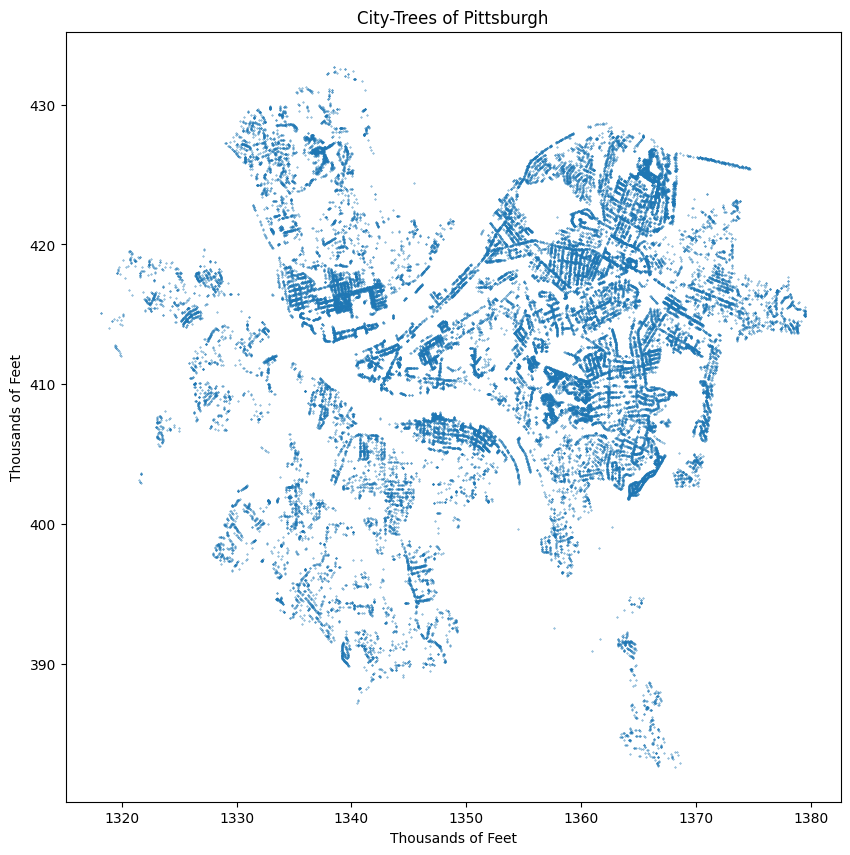

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.set_title("City-Trees of Pittsburgh")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v/1000:.0f}'))
ax.set_xlabel("Thousands of Feet")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f'{v/1000:.0f}'))
ax.set_ylabel("Thousands of Feet")
ax.scatter(df_trees["x"], df_trees["y"], s=0.1)

plt.show()